In [1]:
import os
import sys
from pathlib import Path

# Automatically locate and add the 'src' folder to sys.path
project_root = Path(os.path.abspath(''))
src_path = project_root / "src"
if src_path not in sys.path:
    sys.path.insert(0, str(src_path))

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, probplot
import patsy
import statsmodels.formula.api as smf
from scipy.stats import norm

from nvitk import io

import warnings
# from pandas.errors import SettingWithCopyWarning
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
# warnings.filterwarnings('ignore', category=SettingWithCopyWarning)
warnings.filterwarnings('ignore')

In [2]:
db_base_path = Path('/home/imarcoss/NetVolumes/Tierra/LAB_VF-ICH/LAB/MCC LAB/_IgnacioMarcos/LabVF/PESA-Brain/DB/')

db_clinical                   = pd.read_excel(db_base_path / 'PESABrain_Clinical_20260216.xlsx')
db_clinical_all               = pd.read_excel(db_base_path / 'PESABrain_Clinical_AllXNAT_20260216.xlsx')
db_subject_catalog_all        = pd.read_excel(db_base_path / 'PESABrain_SubjectCatalog_AllXNAT_20260216.xlsx')
db_all_ids                    = pd.read_excel(db_base_path / 'PESABrain_All_IDs.xlsx')
db_all_4dflow_ids             = pd.read_excel(db_base_path / 'PESABrain_All_4DFlow_IDs.xlsx')
      
db_hemo                       = pd.read_excel(db_base_path / 'PESABrain_LocHemodynamic_20260406.xlsx')
db_4dflow_loc_tavg_flow       = pd.read_excel(db_base_path / 'PESABrain_4DFlow_LocalizedTimeAvgFlow_20260216.xlsx')
db_4dflow_loc_pi              = pd.read_excel(db_base_path / 'PESABrain_4DFlow_LocalizedPI_20260216.xlsx')
db_4dflow_loc_tseries         = pd.read_excel(db_base_path / 'PESABrain_4DFlow_LocalizedTimeseriesFlow_Wide_20260216.xlsx')

db_asl_desikan_avg_perfusion  = pd.read_excel(db_base_path / 'PESABrain_ASLPerfusion_ThrMeanCBF_20260216.xlsx')
db_asl_vascular_avg_perfusion = pd.read_excel(db_base_path / 'PESABrain_ASLPerfusion_VascularAtlas_MeanCBF_20260216.xlsx')

db_echo_carotide_plaque_vol   = pd.read_excel(db_base_path / 'PESABrain_Echography_CarotidePlaque_20260216.xlsx')
db_tac                        = pd.read_excel(db_base_path / 'PESABrain_TAC_20260318.xlsx')
db_apoe                       = pd.read_excel(db_base_path / 'PESABrain_APOE_20260318.xlsx')


subjects_all = db_all_ids.patient_id.unique()
subjects_4dflow_all = db_all_4dflow_ids.patient_id.unique()
subjects_4dflow_available = db_4dflow_loc_tavg_flow.patient_id.unique()

print(f'Total subjects: {len(subjects_all)}')
print(f'Total 4DFlow subjects: {len(subjects_4dflow_all)}')
print(f'Total 4DFlow available subjects: {len(subjects_4dflow_available)}')

flow_cols = [col for col in db_hemo.columns if 'flow' in col]
for col in flow_cols:
    db_hemo[col] *= 60

db_hemo

Total subjects: 1001
Total 4DFlow subjects: 554
Total 4DFlow available subjects: 356


,patient_id,lica_flow,lica_area,lica_psv,lica_pi,lica_ri,rica_flow,rica_area,rica_psv,rica_pi,...,laca_asl,lbasi_asl,lmca_asl,lpca_asl,raca_asl,rbasi_asl,rmca_asl,rpca_asl,ws_asl,age_c
0,PESA1006009,267.035802,0.185990,51.072498,0.701133,0.501405,281.351906,0.155110,73.136002,0.727263,...,57.143509,58.281823,54.680104,57.625703,59.824013,63.175530,56.890992,59.861298,50.179122,5.064663
1,PESA10061584,94.844843,0.052847,50.658012,0.639911,0.467598,207.560577,0.188077,41.568962,0.698219,...,41.327638,33.866011,42.331802,29.951558,38.817922,32.273991,38.077766,29.311260,27.110815,6.464663
2,PESA10067929,323.586469,0.177349,67.100998,0.773645,0.534933,355.117301,0.199957,65.818504,0.796976,...,57.639169,62.794067,59.787938,55.884712,62.024153,63.693485,61.698699,59.397221,55.872769,6.734663
3,PESA10086976,303.364359,0.196693,58.151039,0.540127,0.430462,0.814246,0.001630,13.636579,0.847596,...,55.158655,48.004188,57.096666,52.363161,58.912566,52.867965,60.446592,55.156248,51.348714,-4.615337
4,PESA10112400,325.856177,0.228517,56.140694,0.707761,0.513888,330.478438,0.266829,44.318054,0.791426,...,56.217818,34.247757,50.796234,42.679280,57.518873,34.655802,51.371223,42.014865,46.215967,-4.065337
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
351,PESA9897316,283.497145,0.236773,41.451118,0.709040,0.513624,262.646432,0.213102,41.385551,0.782386,...,55.688677,45.282989,56.265623,44.485849,55.840209,45.742534,53.550264,44.541762,42.002036,-2.455337
352,PESA9928801,314.992869,0.263817,55.139935,0.850857,0.564423,370.991649,0.261477,57.409889,0.870882,...,55.200065,58.985057,54.112889,55.737723,57.223394,56.795652,58.131150,60.351909,49.882072,4.324663
353,PESA9935104,352.592480,0.225063,60.434376,0.753206,0.530925,199.660541,0.175714,44.200207,0.735158,...,52.431084,40.572026,54.236169,43.115527,50.796183,38.552160,54.130418,40.179098,46.629408,2.784663
354,PESA9947716,350.185589,0.246978,55.364765,0.807655,0.555005,358.434131,0.252401,54.714527,0.811330,...,61.730753,49.490786,66.492889,50.254449,66.573847,50.701696,72.198803,49.731519,55.293241,1.324663


In [3]:
VESSEL_TERRITORIES_MAP = {
    "Internal Carotid Arteries": ["lica", "rica"],
    "Venous Drainage": ["sssv", "strv", "ltsv", "rtsv"],
    "Anterior Circulation": [
        "lmca",
        "rmca",
        "laca",
        "raca",
    ],
    "Posterior Circulation": ["basi", "lpca", "rpca"],
}

base_territory_palette = {
    "MCA": "#1f77b4",
    "ACA": "#ff7f0e",
    "PCA": "#2ca02c",
    "ICA": "#d62728",
    "Basilar": "#9467bd",
    "Venous Drainage": "#8c564b",
    "Watershed": "#e377c2",
}

cmap = 'coolwarm'

cacs_order = ['None', 'Mild', 'Moderate', 'Severe']

pair_specs = [
    {
        "pair_label": "MCA",
        "pair_family": "Direct territorial",
        "macro_key": "MCA",
        "micro_key": "MCA",
        "interpretation": "Direct arterial territory match",
    },
    {
        "pair_label": "ACA",
        "pair_family": "Direct territorial",
        "macro_key": "ACA",
        "micro_key": "ACA",
        "interpretation": "Direct arterial territory match",
    },
    {
        "pair_label": "PCA",
        "pair_family": "Direct territorial",
        "macro_key": "PCA",
        "micro_key": "PCA",
        "interpretation": "Direct arterial territory match",
    },
    {
        "pair_label": "Basilar",
        "pair_family": "Direct territorial",
        "macro_key": "Basilar",
        "micro_key": "Basilar",
        "interpretation": "Direct arterial territory match",
    },
    {
        "pair_label": "ICA -> Anterior perfusion",
        "pair_family": "Upstream supply",
        "macro_key": "ICA",
        "micro_key": "Anterior perfusion",
        "interpretation": "ICA as proximal supply to the anterior circulation",
    },
    {
        "pair_label": "Proximal supply -> Watershed",
        "pair_family": "Borderzone supply",
        "macro_key": "Proximal supply",
        "micro_key": "Watershed",
        "interpretation": "Borderzone perfusion paired to aggregate proximal inflow",
    },
    {
        "pair_label": "Venous drainage -> Global perfusion",
        "pair_family": "Outflow coupling",
        "macro_key": "Venous Drainage",
        "micro_key": "Global perfusion",
        "interpretation": "Venous outflow paired to overall perfusion burden",
    },
]

combined_pair_order = [
    "MCA",
    "ACA",
    "PCA",
    "Basilar",
    "ICA -> Anterior perfusion",
    "Proximal supply -> Watershed",
    "Venous drainage -> Global perfusion",
]

In [5]:
db = db_hemo[[
    'patient_id', 'age_c', 'sex', 'tacsctot_group', 'Hematocrit', 
    'BPXSYM', 'BPXDIM', 'a2vpb', 'apcpi', 'ipb', 'sys_dias_delta', 
    'lmca_flow', 'rmca_flow', 'laca_flow', 'raca_flow', 'basi_flow',
    'lpca_flow', 'rpca_flow', 'lica_flow', 'rica_flow', 'sssv_flow',
    'strv_flow', 'ltsv_flow', 'rtsv_flow', 
    'lmca_asl', 'rmca_asl', 'laca_asl', 'raca_asl', 'lbasi_asl', 'rbasi_asl',
    'lpca_asl', 'rpca_asl', 'ws_asl'
]].copy()

db['pp'] = db['BPXSYM'] - db['BPXDIM']
db['map'] = db['BPXDIM'] + 1/3 * db['pp']

db

,patient_id,age_c,sex,tacsctot_group,Hematocrit,BPXSYM,BPXDIM,a2vpb,apcpi,ipb,...,rmca_asl,laca_asl,raca_asl,lbasi_asl,rbasi_asl,lpca_asl,rpca_asl,ws_asl,pp,map
0,PESA1006009,5.064663,1,g0,47.0,124.0,75.0,1.092251,0.939155,0.739829,...,56.890992,57.143509,59.824013,58.281823,63.175530,57.625703,59.861298,50.179122,49.0,91.333333
1,PESA10061584,6.464663,1,g2,48.0,138.0,85.0,1.505965,0.855939,0.719334,...,38.077766,41.327638,38.817922,33.866011,32.273991,29.951558,29.311260,27.110815,53.0,102.666667
2,PESA10067929,6.734663,1,g0,42.0,148.0,86.0,1.882628,0.823165,0.768609,...,61.698699,57.639169,62.024153,62.794067,63.693485,55.884712,59.397221,55.872769,62.0,106.666667
3,PESA10086976,-4.615337,0,g0,45.0,111.0,79.0,0.962192,0.982357,0.681850,...,60.446592,55.158655,58.912566,48.004188,52.867965,52.363161,55.156248,51.348714,32.0,89.666667
4,PESA10112400,-4.065337,1,g0,48.0,147.0,89.0,1.788935,1.016581,0.718884,...,51.371223,56.217818,57.518873,34.247757,34.655802,42.679280,42.014865,46.215967,58.0,108.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
351,PESA9897316,-2.455337,1,g1,52.0,107.0,68.0,2.669613,1.121102,0.721854,...,53.550264,55.688677,55.840209,45.282989,45.742534,44.485849,44.541762,42.002036,39.0,81.000000
352,PESA9928801,4.324663,0,g0,45.0,104.0,73.0,1.334134,1.021586,0.763132,...,58.131150,55.200065,57.223394,58.985057,56.795652,55.737723,60.351909,49.882072,31.0,83.333333
353,PESA9935104,2.784663,0,g0,45.0,122.0,76.0,1.816840,1.014163,0.736039,...,54.130418,52.431084,50.796183,40.572026,38.552160,43.115527,40.179098,46.629408,46.0,91.333333
354,PESA9947716,1.324663,1,g1,42.0,114.0,71.0,1.852452,0.884560,0.825353,...,72.198803,61.730753,66.573847,49.490786,50.701696,50.254449,49.731519,55.293241,43.0,85.333333


          Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  pp       
No. Observations:  180      Method:              REML     
No. Groups:        180      Scale:               42.3538  
Min. group size:   1        Log-Likelihood:      -689.8126
Max. group size:   1        Converged:           Yes      
Mean group size:   1.0                                    
----------------------------------------------------------
           Coef.     Std.Err.     z    P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept  33.706        11.093  3.039 0.002 11.965 55.447
lmca_flow   0.009         0.022  0.415 0.678 -0.034  0.052
rmca_flow   0.002         0.019  0.111 0.911 -0.035  0.039
laca_flow   0.006         0.017  0.366 0.714 -0.027  0.039
raca_flow  -0.013         0.017 -0.807 0.420 -0.046  0.019
basi_flow  -0.014         0.017 -0.824 0.410 -0.047  0.019
lpca_flow   0.016         0.025  0.660 0.509 -0.032  0.065
rpca_flo

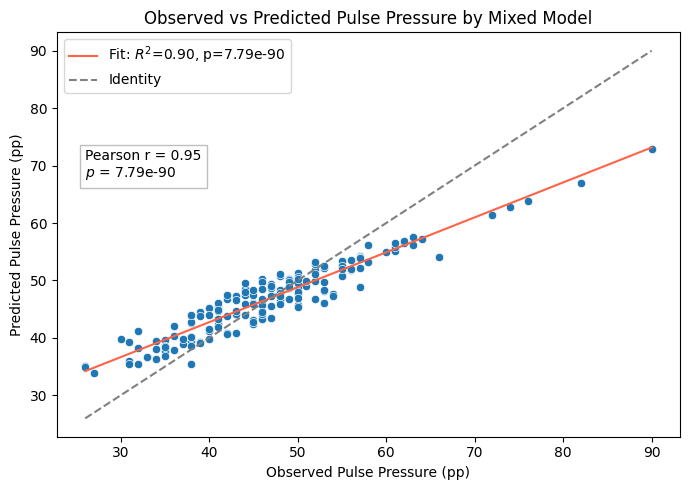

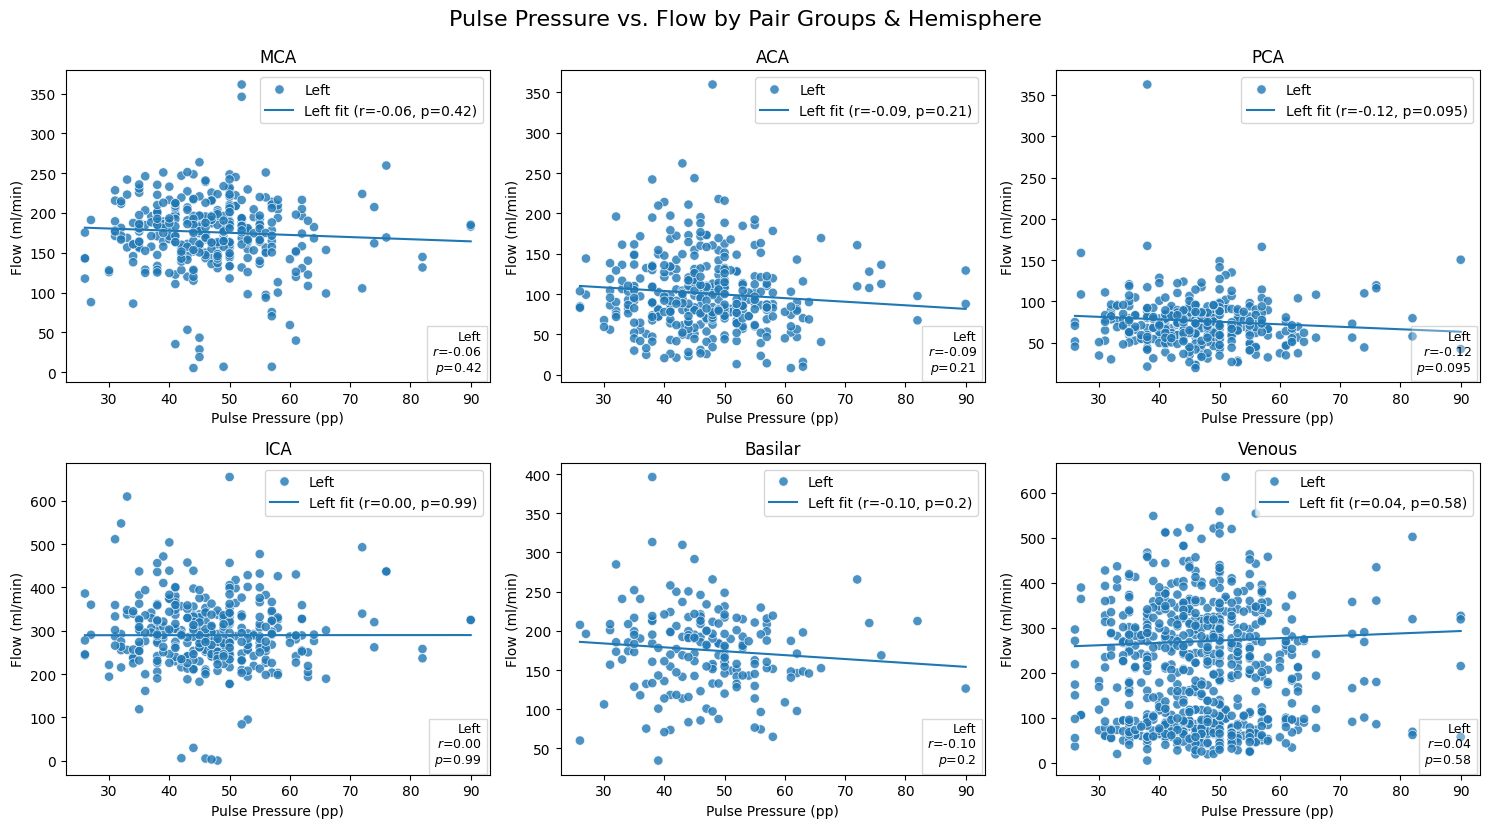

In [14]:
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Mixed model: Predict Pulse Pressure as a function of flow, age, sex, hematocrit
mm_formula = (
    "pp ~ lmca_flow + rmca_flow + laca_flow + raca_flow + "
    "basi_flow + lpca_flow + rpca_flow + lica_flow + rica_flow + "
    "sssv_flow + strv_flow + ltsv_flow + rtsv_flow + age_c + sex + Hematocrit"
)

db = db.dropna().copy()

# Fit the model
md = smf.mixedlm(
    formula=mm_formula,
    data=db,
    groups=db["patient_id"],
    re_formula="1"  # random intercept for patient
)
mm_res = md.fit()
print(mm_res.summary())

# Plot actual vs. predicted pp, with stats and fitted line
db['pp_pred'] = mm_res.fittedvalues

plt.figure(figsize=(7, 5))
sns.scatterplot(x='pp', y='pp_pred', data=db)
# Fit regression line to points
slope, intercept, r_value, p_value, std_err = stats.linregress(db['pp'], db['pp_pred'])
xlims = np.array([db['pp'].min(), db['pp'].max()])
plt.plot(xlims, intercept + slope * xlims, color="tomato", label=f"Fit: $R^2$={r_value**2:.2f}, p={p_value:.2e}")
# Diagonal line
plt.plot(xlims, xlims, '--', color='gray', label="Identity")
plt.xlabel("Observed Pulse Pressure (pp)")
plt.ylabel("Predicted Pulse Pressure (pp)")
plt.title("Observed vs Predicted Pulse Pressure by Mixed Model")
plt.legend()
plt.text(
    xlims[0], db['pp_pred'].max(),
    f"Pearson r = {r_value:.2f}\n$p$ = {p_value:.2e}",
    ha='left', va='top', fontsize=10,
    bbox=dict(facecolor='white', edgecolor='gray', alpha=0.5)
)
plt.tight_layout()
plt.show()

# ------- Additional plot: pp vs. flow by hemisphere and pair groups -------
# Assume hemispheric flows are those with "l" and "r" (left/right), handled in pairs.
hemi_flow_pairs = [
    ('lmca_flow', 'Left MCA'), ('rmca_flow', 'Right MCA'),
    ('laca_flow', 'Left ACA'), ('raca_flow', 'Right ACA'),
    ('lpca_flow', 'Left PCA'), ('rpca_flow', 'Right PCA'),
    ('lica_flow', 'Left ICA'), ('rica_flow', 'Right ICA')
]
pair_meta = {
    'MCA': ['lmca_flow', 'rmca_flow'], 
    'ACA': ['laca_flow', 'raca_flow'],
    'PCA': ['lpca_flow', 'rpca_flow'],
    'ICA': ['lica_flow', 'rica_flow'],
    'Basilar': ['basi_flow'],
    'Venous': ['sssv_flow', 'strv_flow', 'ltsv_flow', 'rtsv_flow'],
}
# Multi-panel plot: for each pair group, plot pp vs. all related flows, stratified by hemisphere/group

ncols = 3
groups = list(pair_meta.keys())
nrows = int(np.ceil(len(groups) / ncols))

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols,4*nrows), squeeze=False)
for i, (group, flows) in enumerate(pair_meta.items()):
    ax = axs[i // ncols, i % ncols]
    data = []
    label_map = {}
    for flow in flows:
        if flow in db.columns:
            if 'l' in flow:
                label = "Left"
            elif 'r' in flow:
                label = "Right"
            else:
                label = group  # e.g. Basilar or Venous
            plot_df = db[['pp', flow]].rename(columns={flow: 'flow'}).copy()
            plot_df['flow_name'] = label
            data.append(plot_df)
            label_map[label] = flow
    if not data:
        continue
    plot_data = pd.concat(data)
    sns.scatterplot(x='pp', y='flow', hue='flow_name', data=plot_data, ax=ax, s=45, alpha=0.8, legend='auto')
    # Fit and plot regression for each
    for label, flow in label_map.items():
        points = db[['pp', flow]].dropna()
        if len(points) > 2:
            slope, intercept, r, p, _ = stats.linregress(points['pp'], points[flow])
            xfit = np.linspace(points['pp'].min(), points['pp'].max(), 100)
            yfit = intercept + slope * xfit
            ax.plot(xfit, yfit, label=f"{label} fit (r={r:.2f}, p={p:.2g})")
            # Annotate with stats at top right
            ax.annotate(f"{label}\n$r$={r:.2f}\n$p$={p:.2g}", 
                        xy=(0.98, 0.02), xycoords='axes fraction', ha='right', va='bottom', fontsize=9,
                        bbox=dict(facecolor='white', edgecolor='gray', alpha=0.3))
    ax.set_xlabel("Pulse Pressure (pp)")
    ax.set_ylabel("Flow (ml/min)")
    ax.set_title(group)
    ax.legend()
# remove empty axes if any
for j in range(i+1, nrows*ncols):
    fig.delaxes(axs[j//ncols, j%ncols])
plt.tight_layout()
plt.suptitle("Pulse Pressure vs. Flow by Pair Groups & Hemisphere", y=1.03, fontsize=16)
plt.show()

In [7]:
mm_res = _fit_mm_hemi(
    db, feature = 'flow',
    mm_formula = f"flow ~ C(tacsctot_group, Treatment('None')) * C(hemi, Treatment('Left'))  + age_c + sex + Hematocrit",
    groups_name = "patient_id",
    re_formula = "0 + C(territory_base)",
    vc_formula = {"patient": "0 + C(patient_id)"},
    print_emm = True
)

ValueError: Shape mismatch between endog/exog and extra 2d arrays given to model.